In [10]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import resample

import joblib


In [11]:
# função que extrai média a* e b* de uma imagem
def extract_mean_lab(image_path: str):
    img = cv2.imread(str(image_path))
    if img is None:
        raise ValueError(f"Imagem não encontrada: {image_path}")
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    # a* está no canal 1, b* no canal 2
    a_mean = float(lab[:, :, 1].mean())
    b_mean = float(lab[:, :, 2].mean())
    return a_mean, b_mean


In [12]:
# carregar todas as imagens de teste/green|red|blue e extrair a*,b*
def load_ab_from_folders(base_folder="teste", verbose=True):
    base_path = Path(base_folder)
    if not base_path.exists():
        raise FileNotFoundError(f"Pasta '{base_folder}' não encontrada")
    
    label_map = {"green": 0, "red": 1, "blue": 2}
    records = []
    
    for color in label_map.keys():
        color_path = base_path / color
        if not color_path.exists():
            if verbose:
                print(f"[AVISO] pasta ausente: {color_path}")
            continue
        images = list(color_path.glob("*"))
        for img_path in tqdm(images, desc=f"Carregando {color}", unit="img"):
            a, b = extract_mean_lab(img_path)
            records.append({"image": img_path.name, "a": a, "b": b, "Color": color, "label": label_map[color]})
    
    df = pd.DataFrame(records)
    if verbose:
        print("Total samples:", len(df))
        print(df['Color'].value_counts())
    return df

# Exemplo de uso:
# df = load_ab_from_folders("teste")


In [13]:
# balanceamento por classe: method='undersample' ou 'oversample'
def balance_dataframe(df: pd.DataFrame, method="undersample", random_state=42):
    """
    Retorna um novo DataFrame balanceado.
    method: 'undersample' (reduce to minority) or 'oversample' (increase to majority)
    """
    groups = [g for _, g in df.groupby("label")]
    counts = [len(g) for g in groups]
    if len(counts) == 0:
        return df
    if method == "undersample":
        min_count = min(counts)
        balanced = []
        for _, g in df.groupby("label"):
            if len(g) > min_count:
                g_res = resample(g, replace=False, n_samples=min_count, random_state=random_state)
            else:
                g_res = g
            balanced.append(g_res)
        df_bal = pd.concat(balanced).sample(frac=1, random_state=random_state).reset_index(drop=True)
        return df_bal
    elif method == "oversample":
        max_count = max(counts)
        balanced = []
        for _, g in df.groupby("label"):
            if len(g) < max_count:
                g_res = resample(g, replace=True, n_samples=max_count, random_state=random_state)
            else:
                g_res = g
            balanced.append(g_res)
        df_bal = pd.concat(balanced).sample(frac=1, random_state=random_state).reset_index(drop=True)
        return df_bal
    else:
        raise ValueError("method deve ser 'undersample' ou 'oversample'")


In [14]:
# pipeline de preparação: carregar, balancear, split (train/val/test)
def prepare_dataset(base_folder="teste", balance_method="undersample", test_size=0.2, val_size=0.1, random_state=42):
    # 1) carregar
    df = load_ab_from_folders(base_folder, verbose=True)
    if df.empty:
        raise RuntimeError("Dataset vazio após carga.")
    
    # 2) balancear
    df_bal = balance_dataframe(df, method=balance_method, random_state=random_state)
    print("Distribuição após balanceamento:")
    print(df_bal['Color'].value_counts())
    
    # 3) features e labels
    X = df_bal[['a', 'b']].values.astype(np.float32)
    y = df_bal['label'].values.astype(int)
    
    # 4) split train / temp
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=(test_size + val_size), stratify=y, random_state=random_state
    )
    # 5) split temp -> val / test (proporcional)
    val_relative = val_size / (test_size + val_size)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=1 - val_relative, stratify=y_temp, random_state=random_state
    )
    
    print("Tamanhos: train=%d | val=%d | test=%d" % (len(X_train), len(X_val), len(X_test)))
    
    # 6) Construir DataFrames informativos (opcional)
    df_train = pd.DataFrame(X_train, columns=['a','b'])
    df_train['label'] = y_train
    df_val = pd.DataFrame(X_val, columns=['a','b'])
    df_val['label'] = y_val
    df_test = pd.DataFrame(X_test, columns=['a','b'])
    df_test['label'] = y_test
    
    return (X_train, y_train), (X_val, y_val), (X_test, y_test), df_bal


In [15]:
# treinando MLP simples
def train_mlp(X_train, y_train, hidden_layers=(16,16), max_iter=1000, random_state=42):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(hidden_layer_sizes=hidden_layers,
                              activation='relu',
                              solver='adam',
                              max_iter=max_iter,
                              random_state=random_state))
    ])
    pipe.fit(X_train, y_train)
    return pipe

In [16]:
def evaluate_model(model, X, y, target_names=["green","red","blue"], show_confusion=True):
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    print("Accuracy: %.4f" % acc)
    print(classification_report(y, y_pred, target_names=target_names))
    
    if show_confusion:
        cm = confusion_matrix(y, y_pred)
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        fig, ax = plt.subplots(1, 2, figsize=(14, 5))
        
        # Plot 1: Contagens absolutas
        im1 = ax[0].imshow(cm, interpolation='nearest', cmap='Blues')
        ax[0].set_title("Matriz de Confusão (Contagens)", fontsize=14, pad=15)
        
        # Adicionar valores nas células
        for i in range(len(target_names)):
            for j in range(len(target_names)):
                text = ax[0].text(j, i, f'{cm[i, j]}',
                                ha="center", va="center",
                                color="white" if cm[i, j] > cm.max()/2 else "black",
                                fontsize=12, fontweight='bold')
        
        # Plot 2: Normalizado (%)
        im2 = ax[1].imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
        ax[1].set_title("Matriz de Confusão (Normalizada)", fontsize=14, pad=15)
        
        # Adicionar valores percentuais
        for i in range(len(target_names)):
            for j in range(len(target_names)):
                text = ax[1].text(j, i, f'{cm_norm[i, j]*100:.1f}%',
                                ha="center", va="center",
                                color="white" if cm_norm[i, j] > 0.5 else "black",
                                fontsize=12, fontweight='bold')
        
        # Configurar eixos
        for i in range(2):
            ax[i].set_xticks([0, 1, 2])
            ax[i].set_yticks([0, 1, 2])
            ax[i].set_xticklabels(target_names, fontsize=11)
            ax[i].set_yticklabels(target_names, fontsize=11)
            ax[i].set_xlabel("Predito", fontsize=12)
            ax[i].set_ylabel("Real", fontsize=12)
        
        # Adicionar colorbars
        plt.colorbar(im1, ax=ax[0], fraction=0.046, pad=0.04)
        plt.colorbar(im2, ax=ax[1], fraction=0.046, pad=0.04)
        
        plt.tight_layout()
        plt.show()
    
    return y_pred

In [17]:
def plot_decision_boundary(model, X, y, title="Decision boundary (a*b*)", grid_step=0.5):
    scaler = model.named_steps['scaler']
    classifier = model.named_steps['mlp']
    
    # Grid mais fino para melhor visualização
    a_min, a_max = X[:,0].min() - 10, X[:,0].max() + 10
    b_min, b_max = X[:,1].min() - 10, X[:,1].max() + 10
    aa, bb = np.meshgrid(np.arange(a_min, a_max, grid_step), 
                         np.arange(b_min, b_max, grid_step))
    grid = np.c_[aa.ravel(), bb.ravel()]
    grid_scaled = scaler.transform(grid)
    zz = classifier.predict(grid_scaled)
    zz = zz.reshape(aa.shape)
    
    # Cores RGB para as classes
    colors = ['#2ecc71', '#e74c3c', '#3498db']  # green, red, blue mais vibrantes
    cmap = plt.matplotlib.colors.ListedColormap(colors)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot da fronteira (contourf com alpha baixo)
    contourf = ax.contourf(aa, bb, zz, alpha=0.25, levels=[-0.5, 0.5, 1.5, 2.5], 
                           cmap=cmap, antialiased=True)
    
    # Linhas de contorno para destacar fronteiras
    ax.contour(aa, bb, zz, levels=[-0.5, 0.5, 1.5, 2.5], 
               colors='black', linewidths=1.5, alpha=0.4, linestyles='dashed')
    
    # Scatter dos pontos com bordas
    label_names = ["green", "red", "blue"]
    for lbl in np.unique(y):
        pts = X[y == lbl]
        ax.scatter(pts[:,0], pts[:,1], c=colors[lbl], 
                  label=label_names[lbl], edgecolor='black', 
                  s=60, alpha=0.85, linewidths=1.5)
    
    ax.set_xlabel("a* (verde-vermelho)", fontsize=13, fontweight='bold')
    ax.set_ylabel("b* (azul-amarelo)", fontsize=13, fontweight='bold')
    ax.set_title(title, fontsize=15, fontweight='bold', pad=15)
    ax.legend(loc='upper right', fontsize=11, framealpha=0.9)
    ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)
    
    # Adicionar informação de acurácia no plot
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    ax.text(0.02, 0.98, f'Accuracy: {acc:.2%}', 
            transform=ax.transAxes, fontsize=11,
            verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

Carregando green:   0%|          | 0/4604 [00:00<?, ?img/s]

Carregando red:   0%|          | 0/9200 [00:00<?, ?img/s]

Carregando blue:   0%|          | 0/3450 [00:00<?, ?img/s]

Total samples: 17254
Color
red      9200
green    4604
blue     3450
Name: count, dtype: int64
Distribuição após balanceamento:
Color
blue     3450
green    3450
red      3450
Name: count, dtype: int64
Tamanhos: train=7244 | val=1035 | test=2071
== VAL SET ==
Accuracy: 1.0000
              precision    recall  f1-score   support

       green       1.00      1.00      1.00       345
         red       1.00      1.00      1.00       345
        blue       1.00      1.00      1.00       345

    accuracy                           1.00      1035
   macro avg       1.00      1.00      1.00      1035
weighted avg       1.00      1.00      1.00      1035



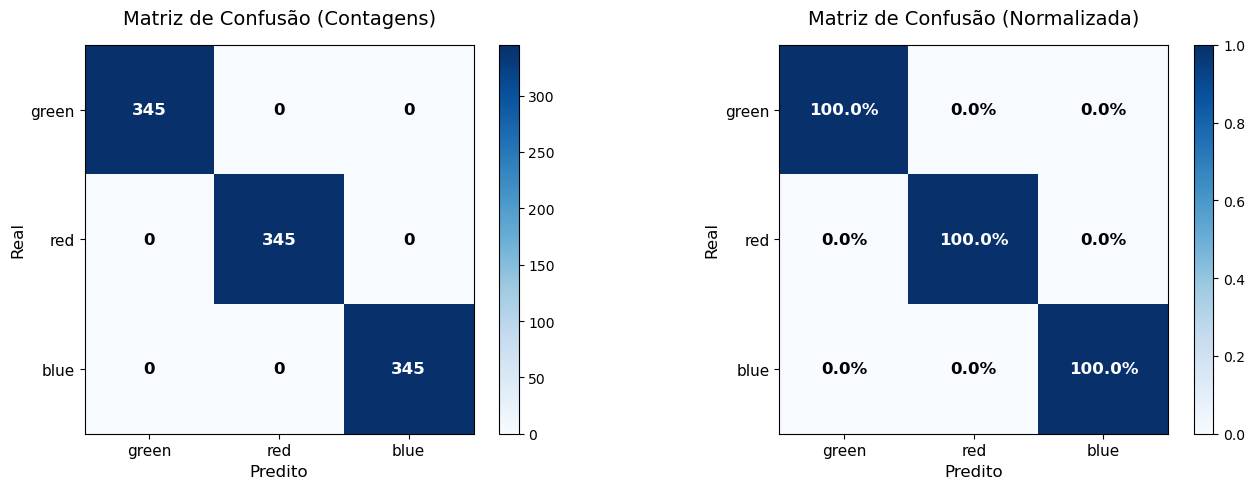

== TEST SET ==
Accuracy: 1.0000
              precision    recall  f1-score   support

       green       1.00      1.00      1.00       690
         red       1.00      1.00      1.00       690
        blue       1.00      1.00      1.00       691

    accuracy                           1.00      2071
   macro avg       1.00      1.00      1.00      2071
weighted avg       1.00      1.00      1.00      2071



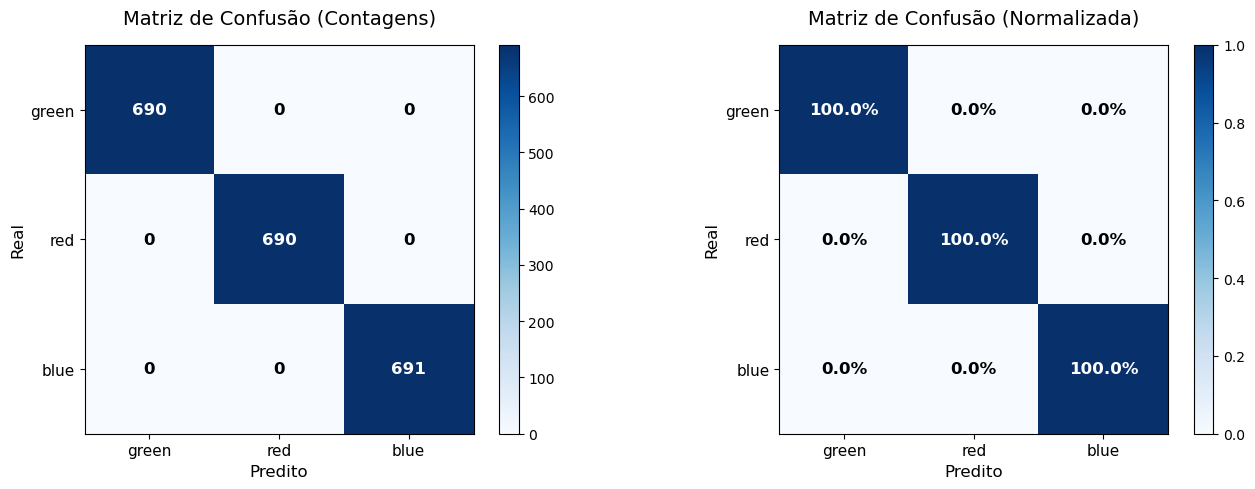

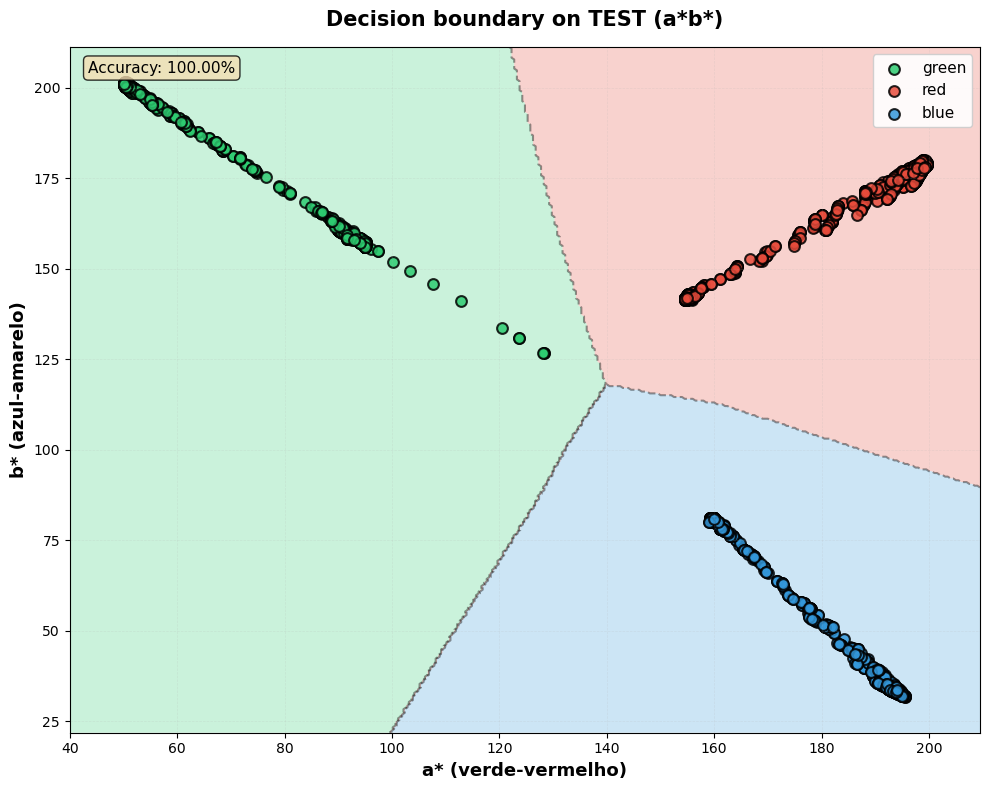

Modelo salvo em mlp_ab_model.joblib


In [18]:
# execução completa
# 1) preparar dataset (balanceado por undersample)
(X_train, y_train), (X_val, y_val), (X_test, y_test), df_bal = prepare_dataset(
    base_folder=r"dataset\teste",
    balance_method="undersample",  # ou "oversample"
    test_size=0.2,
    val_size=0.1,
    random_state=42
)

# 2) treinar
model = train_mlp(X_train, y_train, hidden_layers=(16,16), max_iter=2000, random_state=42)

# 3) avaliar em val (checagem rápida)
print("== VAL SET ==")
evaluate_model(model, X_val, y_val)

# 4) avaliar em test (resultado final)
print("== TEST SET ==")
evaluate_model(model, X_test, y_test)

# 5) plotar fronteira e pontos de teste
plot_decision_boundary(model, X_test, y_test, title="Decision boundary on TEST (a*b*)")

# 6) salvar modelo (opcional)
joblib.dump(model, "mlp_ab_model.joblib")
print("Modelo salvo em mlp_ab_model.joblib")


In [ ]:
# ===== carregar modelo =====
import tempfile
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image

model = joblib.load("mlp_ab_model.joblib")
LABEL_MAP_INV = {0: "green", 1: "red", 2: "blue"}

# ===== função de classificação =====
def classify_image(image_path: str):
    a, b = extract_mean_lab(image_path)
    X = np.array([[a, b]], dtype=np.float32)

    pred = model.predict(X)[0]
    probs = model.predict_proba(X)[0]

    return LABEL_MAP_INV[pred], probs, a, b


# ===== widgets =====
upload = widgets.FileUpload(
    accept="image/*",
    multiple=False,
    description="Upload",
)

button = widgets.Button(
    description="Classificar",
    button_style="success",
)

output = widgets.Output()


# ===== ação do botão =====
def on_classify_clicked(b):
    with output:
        clear_output()

        if not upload.value:
            print("Nenhuma imagem enviada.")
            return

        file_info = upload.value[0]
        content = file_info.content
        filename = file_info.name

        with tempfile.NamedTemporaryFile(delete=False, suffix=Path(filename).suffix) as tmp:
            tmp.write(content)
            tmp_path = tmp.name

        # Criar figura com subplots
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # ===== PLOT 1: Imagem original =====
        img = Image.open(tmp_path)
        axes[0].imshow(img)
        axes[0].axis("off")
        axes[0].set_title(f"Imagem: {filename}", fontsize=12, fontweight='bold')

        # ===== PLOT 2: Gráfico de probabilidades =====
        label, probs, a, b = classify_image(tmp_path)
        
        colors_plot = ['#2ecc71', '#e74c3c', '#3498db']
        labels_plot = ['green', 'red', 'blue']
        
        bars = axes[1].barh(labels_plot, probs * 100, color=colors_plot, alpha=0.8, edgecolor='black')
        axes[1].set_xlabel('Probabilidade (%)', fontsize=12, fontweight='bold')
        axes[1].set_title('Confiança da Predição', fontsize=12, fontweight='bold')
        axes[1].set_xlim(0, 100)
        axes[1].grid(axis='x', alpha=0.3, linestyle='--')
        
        # Adicionar valores nas barras
        for i, (bar, prob) in enumerate(zip(bars, probs)):
            width = bar.get_width()
            axes[1].text(width + 2, bar.get_y() + bar.get_height()/2, 
                        f'{prob*100:.1f}%',
                        ha='left', va='center', fontsize=11, fontweight='bold')
        
        # Destacar a classe prevista
        max_idx = np.argmax(probs)
        bars[max_idx].set_linewidth(3)
        bars[max_idx].set_edgecolor('gold')
        
        plt.tight_layout()
        plt.show()

        # ===== INFORMAÇÕES TEXTUAIS =====
        print("=" * 50)
        print("RESULTADO DA CLASSIFICAÇÃO")
        print("=" * 50)
        print(f"Classe prevista: {label.upper()}")
        print(f"Valores Lab: a*={a:.2f} | b*={b:.2f}")
        print(f"Confiança: {probs[max_idx]*100:.1f}%")
        print("=" * 50)
        print("\nDistribuição de probabilidades:")
        for i, (name, p) in enumerate(zip(labels_plot, probs)):
            bar = "█" * int(p * 30)
            print(f"  {name:6s}: {bar} {p*100:5.1f}%")


button.on_click(on_classify_clicked)

# ===== layout com estilo =====
box_layout = widgets.Layout(
    display='flex',
    flex_flow='column',
    align_items='center',
    width='100%',
    border='2px solid #ddd',
    padding='20px',
    border_radius='10px'
)

title = widgets.HTML(
    value="<h2 style='text-align: center; color: #333;'>Classificador de Cores MLP</h2>"
)

instructions = widgets.HTML(
    value="<p style='text-align: center; color: #666;'>Faça upload de uma imagem para classificar a cor dominante</p>"
)

display(widgets.VBox([title, instructions, upload, button, output], layout=box_layout))

AttributeError: module 'matplotlib.widgets' has no attribute 'FileUpload'

In [24]:
# ===== carregar modelo =====
import tempfile
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image

model = joblib.load("mlp_ab_model.joblib")
LABEL_MAP_INV = {0: "green", 1: "red", 2: "blue"}

# ===== função de classificação =====
def classify_image(image_path: str):
    a, b = extract_mean_lab(image_path)
    X = np.array([[a, b]], dtype=np.float32)

    pred = model.predict(X)[0]
    probs = model.predict_proba(X)[0]

    return LABEL_MAP_INV[pred], probs, a, b


# ===== widgets =====
upload = widgets.FileUpload(
    accept="image/*",
    multiple=False,
    description="Upload",
)

button = widgets.Button(
    description="Classificar",
    button_style="success",
)

output = widgets.Output()


# ===== ação do botão =====
def on_classify_clicked(b):
    with output:
        clear_output()

        if not upload.value:
            print("Nenhuma imagem enviada.")
            return

        file_info = upload.value[0]
        content = file_info.content
        filename = file_info.name

        with tempfile.NamedTemporaryFile(delete=False, suffix=Path(filename).suffix) as tmp:
            tmp.write(content)
            tmp_path = tmp.name

        # Criar figura com subplots
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # ===== PLOT 1: Imagem original =====
        img = Image.open(tmp_path)
        axes[0].imshow(img)
        axes[0].axis("off")
        axes[0].set_title(f"Imagem: {filename}", fontsize=12, fontweight='bold')

        # ===== PLOT 2: Gráfico de probabilidades =====
        label, probs, a, b = classify_image(tmp_path)
        
        colors_plot = ['#2ecc71', '#e74c3c', '#3498db']
        labels_plot = ['green', 'red', 'blue']
        
        bars = axes[1].barh(labels_plot, probs * 100, color=colors_plot, alpha=0.8, edgecolor='black')
        axes[1].set_xlabel('Probabilidade (%)', fontsize=12, fontweight='bold')
        axes[1].set_title('Confiança da Predição', fontsize=12, fontweight='bold')
        axes[1].set_xlim(0, 100)
        axes[1].grid(axis='x', alpha=0.3, linestyle='--')
        
        # Adicionar valores nas barras
        for i, (bar, prob) in enumerate(zip(bars, probs)):
            width = bar.get_width()
            axes[1].text(width + 2, bar.get_y() + bar.get_height()/2, 
                        f'{prob*100:.1f}%',
                        ha='left', va='center', fontsize=11, fontweight='bold')
        
        # Destacar a classe prevista
        max_idx = np.argmax(probs)
        bars[max_idx].set_linewidth(3)
        bars[max_idx].set_edgecolor('gold')
        
        plt.tight_layout()
        plt.show()

        # ===== INFORMAÇÕES TEXTUAIS =====
        print("=" * 50)
        print("RESULTADO DA CLASSIFICAÇÃO")
        print("=" * 50)
        print(f"Classe prevista: {label.upper()}")
        print(f"Valores Lab: a*={a:.2f} | b*={b:.2f}")
        print(f"Confiança: {probs[max_idx]*100:.1f}%")
        print("=" * 50)
        print("\nDistribuição de probabilidades:")
        for i, (name, p) in enumerate(zip(labels_plot, probs)):
            bar = "█" * int(p * 30)
            print(f"  {name:6s}: {bar} {p*100:5.1f}%")


button.on_click(on_classify_clicked)

# ===== layout com estilo =====
box_layout = widgets.Layout(
    display='flex',
    flex_flow='column',
    align_items='center',
    width='100%',
    border='2px solid #ddd',
    padding='20px',
    border_radius='10px'
)

title = widgets.HTML(
    value="<h2 style='text-align: center; color: #333;'>Classificador de Cores MLP</h2>"
)

instructions = widgets.HTML(
    value="<p style='text-align: center; color: #666;'>Faça upload de uma imagem para classificar a cor dominante</p>"
)

display(widgets.VBox([title, instructions, upload, button, output], layout=box_layout))

In [26]:
def plot_data_distribution(X, y, title="Distribuição dos dados no espaço Lab"):
    """Plot adicional para visualizar a distribuição das classes"""
    colors = ['#2ecc71', '#e74c3c', '#3498db']
    label_names = ["green", "red", "blue"]
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # Plot 1: Scatter 2D com densidade
    for lbl in np.unique(y):
        pts = X[y == lbl]
        axes[0].scatter(pts[:,0], pts[:,1], c=colors[lbl], 
                       label=f"{label_names[lbl]} (n={len(pts)})",  # ← contagem
                       alpha=0.6, s=40, edgecolor='black', linewidth=0.5)
    axes[0].set_xlabel("a*", fontsize=12)
    axes[0].set_ylabel("b*", fontsize=12)
    axes[0].set_title("Distribuição 2D", fontsize=13, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Histograma de a* com estatísticas
    for lbl in np.unique(y):
        pts = X[y == lbl, 0]
        mean_val = pts.mean()
        std_val = pts.std()
        axes[1].hist(pts, bins=30, alpha=0.6, 
                    label=f"{label_names[lbl]} (μ={mean_val:.1f}, σ={std_val:.1f})",
                    color=colors[lbl], edgecolor='black', linewidth=0.5)
    axes[1].set_xlabel("a* (verde-vermelho)", fontsize=12)
    axes[1].set_ylabel("Frequência", fontsize=12)
    axes[1].set_title("Distribuição de a*", fontsize=13, fontweight='bold')
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3, axis='y')
    
    # Plot 3: Histograma de b* com estatísticas
    for lbl in np.unique(y):
        pts = X[y == lbl, 1]
        mean_val = pts.mean()
        std_val = pts.std()
        axes[2].hist(pts, bins=30, alpha=0.6, 
                    label=f"{label_names[lbl]} (μ={mean_val:.1f}, σ={std_val:.1f})",
                    color=colors[lbl], edgecolor='black', linewidth=0.5)
    axes[2].set_xlabel("b* (azul-amarelo)", fontsize=12)
    axes[2].set_ylabel("Frequência", fontsize=12)
    axes[2].set_title("Distribuição de b*", fontsize=13, fontweight='bold')
    axes[2].legend(fontsize=9)
    axes[2].grid(True, alpha=0.3, axis='y')
    
    plt.suptitle(title, fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

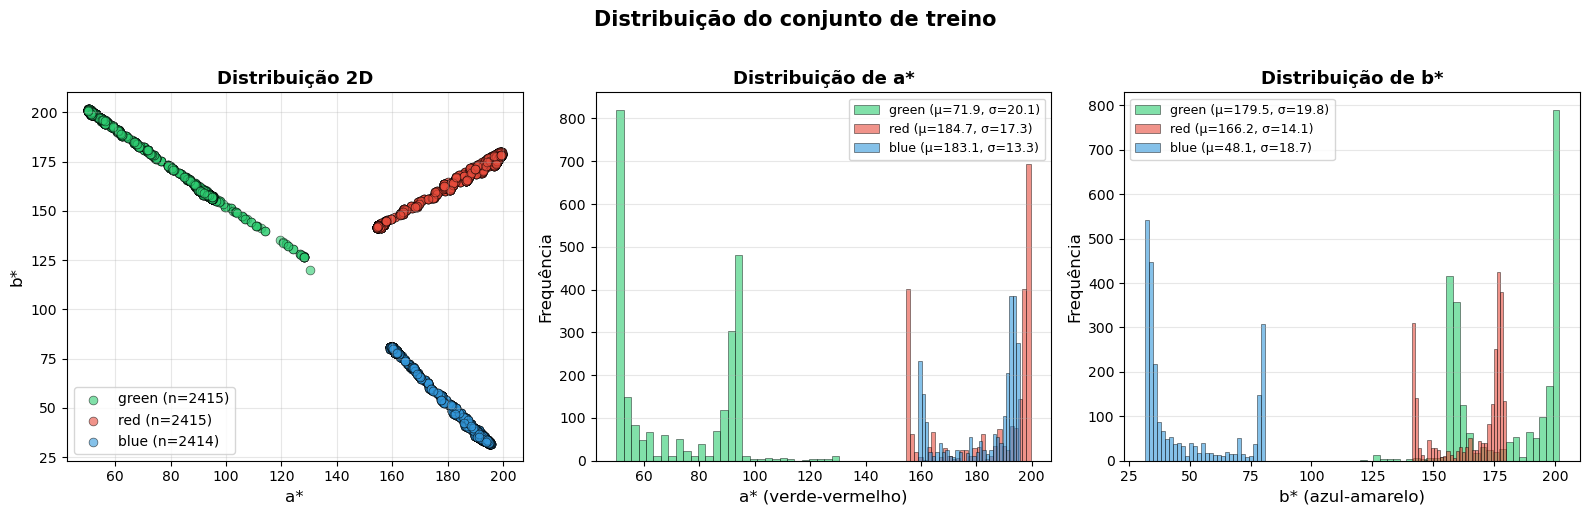

In [27]:
# Após prepare_dataset()
plot_data_distribution(X_train, y_train, "Distribuição do conjunto de treino")